In [26]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 10)

In [4]:
def print_table(rows):
    print(f"\n{'n':>3} {'a_n':>12} {'b_n':>12} {'c_n':>12} {'f(c_n)':>14}")
    for n, a, b, c, fc in rows:
        print(f"{n:>3} {a:>12.6f} {b:>12.6f} {c:>12.6f} {fc:>14.6f}")


def plot_function(f, a, b, root, title, filename):
    margin = 0.25 * (b - a)
    xs = np.linspace(a - margin, b + margin, 400)
    ys = [f(x) for x in xs]
    plt.figure()
    plt.axhline(0, color="black", linewidth=0.8)
    plt.plot(xs, ys, label="f(x)")
    plt.plot(root, f(root), "ro", label=f"root ≈ {root:.6f}")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.close()


In [5]:
def print_secant_table(rows):
    print(f"\n{'n':>3} {'x0':>12} {'x1':>12} {'x2':>12} {'f(x2)':>14} {'err':>12}")
    for n, x0, x1, x2, f2, err in rows:
        print(f"{n:>3} {x0:>12.6f} {x1:>12.6f} {x2:>12.6f} {f2:>14.6f} {err:>12.6e}")


def print_newton_table(rows):
    print(f"\n{'n':>3} {'x':>12} {'f(x)':>14} {chr(39)+'f(x)':>12} {'x_new':>12} {'err':>12}")
    for n, x, fx, dfx, x_new, err in rows:
        print(f"{n:>3} {x:>12.6f} {fx:>14.6f} {dfx:>12.6f} {x_new:>12.6f} {err:>12.6e}")


In [6]:
def find_root(func, a, b, eps, next_c, max_iter=200):
    func_a, func_b = func(a), func(b)
    if func_a * func_b > 0:
        raise ValueError("f(a) and f(b) must have opposite signs")

    rows = []
    n = 0
    c = func_c = width = 0

    while n <= max_iter:
        c = next_c(a, b, func_a, func_b)
        func_c = func(c)
        width = b - a
        n += 1
        rows.append((n, a, b, c, func_c))

        if abs(func_c) < eps or width < eps:
            return c, func_c, width, n, rows

        if func_a * func_c < 0:
            b, func_b = c, func_c
        else:
            a, func_a = c, func_c

    return c, func_c, width, n, rows


def bisection(func, a, b, eps, max_iter=200):
    return find_root(func, a, b, eps, lambda a, b, fa, fb: (a + b) / 2, max_iter)


def false_position(func, a, b, eps, max_iter=200):
    return find_root(func, a, b, eps, lambda a, b, fa, fb: (a * fb - b * fa) / (fb - fa), max_iter)


In [7]:
def secant(func, x0, x1, eps, max_iter=200):
    func_0, func_1 = func(x0), func(x1)

    rows = []
    n = 0
    x2 = func_2 = err = 0

    while n <= max_iter:
        if func_1 - func_0 == 0:
            raise ZeroDivisionError("Division by zero in secant method")

        x2 = x1 - func_1 * (x1 - x0) / (func_1 - func_0)
        func_2 = func(x2)
        err = abs(x2 - x1)
        n += 1
        rows.append((n, x0, x1, x2, func_2, err))

        if abs(func_2) < eps or err < eps:
            return x2, func_2, err, n, rows

        x0, func_0 = x1, func_1
        x1, func_1 = x2, func_2

    return x2, func_2, err, n, rows


def newton_raphson(func, derivative_func, x0, eps, max_iter=200):
    rows = []
    n = 0
    x = x0
    x_new = f_new = err = 0

    while n <= max_iter:
        func_x = func(x)
        derivative_func_x = derivative_func(x)
        if derivative_func_x == 0:
            raise ZeroDivisionError("Zero derivative in Newton-Raphson method")

        x_new = x - func_x / derivative_func_x
        err = abs(x_new - x)
        n += 1
        rows.append((n, x, func_x, derivative_func_x, x_new, err))

        func_new = func(x_new)
        if abs(func_new) < eps or err < eps:
            return x_new, func_new, err, n, rows

        x = x_new

    return x_new, f_new, err, n, rows


In [8]:
METHODS = {
    "bisection": {
        "solve": bisection,
        "title": "BISECTION METHOD",
        "output_dir": "bisection",
        "tasks": [
            ("e^x - x^2 = 0", lambda x: math.exp(x) - x ** 2, (-2, 0), 0.001),
            ("x^3 - x - 2 = 0", lambda x: x ** 3 - x - 2, (1, 2), 1e-5),
            ("cos(x) - x = 0", lambda x: math.cos(x) - x, (0, 1), 1e-6),
            ("x^3 - 4x - 9 = 0", lambda x: x ** 3 - 4 * x - 9, (2, 3), 1e-5),
            ("e^-x - x = 0", lambda x: math.exp(-x) - x, (0, 1), 1e-6),
            ("x^2 - 5 = 0", lambda x: x ** 2 - 5, (2, 3), 1e-5),
        ],
    },
    "false_position": {
        "solve": false_position,
        "title": "FALSE POSITION METHOD",
        "output_dir": "false-position",
        "tasks": [
            ("x^3 - x - 2 = 0", lambda x: x ** 3 - x - 2, (1, 2), 1e-6),
            ("e^-x - x = 0", lambda x: math.exp(-x) - x, (0, 1), 1e-6),
            ("x^3 - 2x - 5 = 0", lambda x: x ** 3 - 2 * x - 5, (2, 3), 1e-6),
            ("ln(x) + x - 3 = 0", lambda x: math.log(x) + x - 3, (2, 3), 1e-6),
            ("cos(x) - x = 0", lambda x: math.cos(x) - x, (0, 1), 1e-6),
        ],
    },
}


def run_task(method_name, task_num=0):
    method = METHODS[method_name]
    label, func, (a, b), eps = method["tasks"][task_num]

    print("=" * 70)
    print(f"{method['title']}: {label} on [{a}, {b}], eps = {eps}")
    print("=" * 70)

    # a) verify sign change
    func_a, func_b = func(a), func(b)
    print(f"\nf({a}) = {func_a:.6f}")
    print(f"f({b}) = {func_b:.6f}")
    if func_a * func_b < 0:
        print("Sign change confirmed: a root exists in the interval.")
    else:
        raise ValueError("No sign change on the given interval")

    # b)+c) run iterations and record the log
    root, f_root, width, n_iter, rows = method["solve"](func, a, b, eps)
    print_table(rows)

    # d) report final result
    print(f"\nApproximate root: {round(root, 4)}")
    print(f"f(root) = {f_root:.6f}")
    print(f"Total number of iterations: {n_iter}")

    plot_function(
        func, a, b, root,
        f"{method['title'].title()}: {label} on [{a}, {b}]",
        f"{method['output_dir']}/{method_name}_task_{task_num + 1}.png",
    )


In [9]:
SECANT_TASKS = [
    ("x^3 - x - 2 = 0", lambda x: x ** 3 - x - 2, 1, 2, 1e-6),
    ("e^-x - x = 0", lambda x: math.exp(-x) - x, 0, 1, 1e-6),
    ("x^3 - 2x - 5 = 0", lambda x: x ** 3 - 2 * x - 5, 2, 3, 1e-6),
    ("x^2 - 5 = 0", lambda x: x ** 2 - 5, 2, 3, 1e-6),
    ("cos(x) - x = 0", lambda x: math.cos(x) - x, 0, 1, 1e-6),
]

NEWTON_TASKS = [
    ("x^3 - x - 2 = 0", lambda x: x ** 3 - x - 2, lambda x: 3 * x ** 2 - 1, 1.5, 1e-6),
    ("x^2 - 5 = 0", lambda x: x ** 2 - 5, lambda x: 2 * x, 2, 1e-6),
    ("e^-x - x = 0", lambda x: math.exp(-x) - x, lambda x: -math.exp(-x) - 1, 0.5, 1e-6),
    ("x^3 - 2x - 5 = 0", lambda x: x ** 3 - 2 * x - 5, lambda x: 3 * x ** 2 - 2, 2, 1e-6),
    ("cos(x) - x = 0", lambda x: math.cos(x) - x, lambda x: -math.sin(x) - 1, 0.5, 1e-6),
]


def run_secant_task(task_num=0):
    label, func, x0, x1, eps = SECANT_TASKS[task_num]

    print("=" * 70)
    print(f"SECANT METHOD: {label}, x0 = {x0}, x1 = {x1}, eps = {eps}")
    print("=" * 70)

    root, f_root, err, n_iter, rows = secant(func, x0, x1, eps)
    print_secant_table(rows)

    print(f"\nApproximate root: {round(root, 4)}")
    print(f"f(root) = {f_root:.6f}")
    print(f"Total number of iterations: {n_iter}")

    lo, hi = min(x0, x1, root) - 0.5, max(x0, x1, root) + 0.5
    plot_function(func, lo, hi, root, f"Secant Method: {label}", f"secant/secant_task_{task_num + 1}.png")


def run_newton_task(task_num=0):
    label, func, dfunc, x0, eps = NEWTON_TASKS[task_num]

    print("=" * 70)
    print(f"NEWTON-RAPHSON METHOD: {label}, x0 = {x0}, eps = {eps}")
    print("=" * 70)

    root, f_root, err, n_iter, rows = newton_raphson(func, dfunc, x0, eps)
    print_newton_table(rows)

    print(f"\nApproximate root: {round(root, 4)}")
    print(f"f(root) = {f_root:.6f}")
    print(f"Total number of iterations: {n_iter}")

    lo, hi = min(x0, root) - 1, max(x0, root) + 1
    plot_function(func, lo, hi, root, f"Newton-Raphson Method: {label}", f"newton/newton_task_{task_num + 1}.png")


In [10]:
user_input = input("Enter task number (0-5): ").strip()
run_task("bisection", int(user_input) if user_input else 0)


BISECTION METHOD: e^x - x^2 = 0 on [-2, 0], eps = 0.001

f(-2) = -3.864665
f(0) = 1.000000
Sign change confirmed: a root exists in the interval.

  n          a_n          b_n          c_n         f(c_n)
  1    -2.000000     0.000000    -1.000000      -0.632121
  2    -1.000000     0.000000    -0.500000       0.356531
  3    -1.000000    -0.500000    -0.750000      -0.090133
  4    -0.750000    -0.500000    -0.625000       0.144636
  5    -0.750000    -0.625000    -0.687500       0.030175
  6    -0.750000    -0.687500    -0.718750      -0.029240
  7    -0.718750    -0.687500    -0.703125       0.000651

Approximate root: -0.7031
f(root) = 0.000651
Total number of iterations: 7


In [11]:
user_input = input("Enter task number (0-4): ").strip()
run_task("false_position", int(user_input) if user_input else 0)


FALSE POSITION METHOD: x^3 - x - 2 = 0 on [1, 2], eps = 1e-06

f(1) = -2.000000
f(2) = 4.000000
Sign change confirmed: a root exists in the interval.

  n          a_n          b_n          c_n         f(c_n)
  1     1.000000     2.000000     1.333333      -0.962963
  2     1.333333     2.000000     1.462687      -0.333339
  3     1.462687     2.000000     1.504019      -0.101818
  4     1.504019     2.000000     1.516331      -0.029895
  5     1.516331     2.000000     1.519919      -0.008675
  6     1.519919     2.000000     1.520957      -0.002509
  7     1.520957     2.000000     1.521258      -0.000725
  8     1.521258     2.000000     1.521344      -0.000209
  9     1.521344     2.000000     1.521370      -0.000060
 10     1.521370     2.000000     1.521377      -0.000017
 11     1.521377     2.000000     1.521379      -0.000005
 12     1.521379     2.000000     1.521379      -0.000001
 13     1.521379     2.000000     1.521380      -0.000000

Approximate root: 1.5214
f(root) = -

In [12]:
user_input = input("Enter task number (0-4): ").strip()
run_secant_task(int(user_input) if user_input else 0)


SECANT METHOD: x^3 - x - 2 = 0, x0 = 1, x1 = 2, eps = 1e-06

  n           x0           x1           x2          f(x2)          err
  1     1.000000     2.000000     1.333333      -0.962963 6.666667e-01
  2     2.000000     1.333333     1.462687      -0.333339 1.293532e-01
  3     1.333333     1.462687     1.531169       0.058626 6.848286e-02
  4     1.462687     1.531169     1.520926      -0.002693 1.024301e-02
  5     1.531169     1.520926     1.521376      -0.000020 4.498962e-04
  6     1.520926     1.521376     1.521380       0.000000 3.391315e-06

Approximate root: 1.5214
f(root) = 0.000000
Total number of iterations: 6


In [13]:
user_input = input("Enter task number (0-4): ").strip()
run_newton_task(int(user_input) if user_input else 0)


NEWTON-RAPHSON METHOD: x^3 - x - 2 = 0, x0 = 1.5, eps = 1e-06

  n            x           f(x)        'f(x)        x_new          err
  1     1.500000      -0.125000     5.750000     1.521739 2.173913e-02
  2     1.521739       0.002137     5.947070     1.521380 3.593245e-04

Approximate root: 1.5214
f(root) = 0.000001
Total number of iterations: 2


## Method Comparison

Compare Bisection, False Position, Secant, and Newton-Raphson on one common equation.

Comparison: x^3 - x - 2 = 0

Method                      Root         f(root)    Iterations
Bisection               1.521380    1.431608e-06            21
False Position          1.521380   -4.205770e-07            13
Secant                  1.521380    7.015478e-09             6
Newton-Raphson          1.521380    5.893874e-07             2


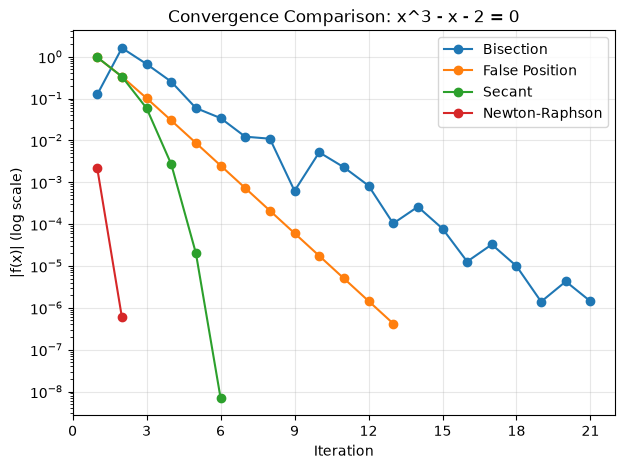

In [22]:
COMPARISON = {
    "label": "x^3 - x - 2 = 0",
    "func": lambda x: x ** 3 - x - 2,
    "dfunc": lambda x: 3 * x ** 2 - 1,
    "a": 1,
    "b": 2,
    "x0": 1.5,
    "eps": 1e-6,
}


def run_comparison():
    label = COMPARISON["label"]
    func = COMPARISON["func"]
    dfunc = COMPARISON["dfunc"]
    a, b, x0, eps = COMPARISON["a"], COMPARISON["b"], COMPARISON["x0"], COMPARISON["eps"]

    results = {
        "Bisection": bisection(func, a, b, eps),
        "False Position": false_position(func, a, b, eps),
        "Secant": secant(func, a, b, eps),
        "Newton-Raphson": newton_raphson(func, dfunc, x0, eps),
    }

    # how to read f achieved at each iteration from its rows
    f_extractors = {
        "Bisection": lambda rows: [abs(r[4]) for r in rows],
        "False Position": lambda rows: [abs(r[4]) for r in rows],
        "Secant": lambda rows: [abs(r[4]) for r in rows],
        "Newton-Raphson": lambda rows: [abs(func(r[4])) for r in rows],
    }

    print("=" * 70)
    print(f"Comparison: {label}")
    print("=" * 70)
    print(f"\n{'Method':<18}{'Root':>14}{'f(root)':>16}{'Iterations':>14}")
    for name, (root, f_root, err, n_iter, rows) in results.items():
        print(f"{name:<18}{root:>14.6f}{f_root:>16.6e}{n_iter:>14}")

    plt.figure()
    for name, (root, f_root, err, n_iter, rows) in results.items():
        f_vals = f_extractors[name](rows)
        plt.semilogy(range(1, n_iter + 1), f_vals, marker="o", label=name)
    plt.title(f"Convergence Comparison: {label}")
    plt.xlabel("Iteration")
    plt.ylabel("|f(x)| (log scale)")
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


run_comparison()


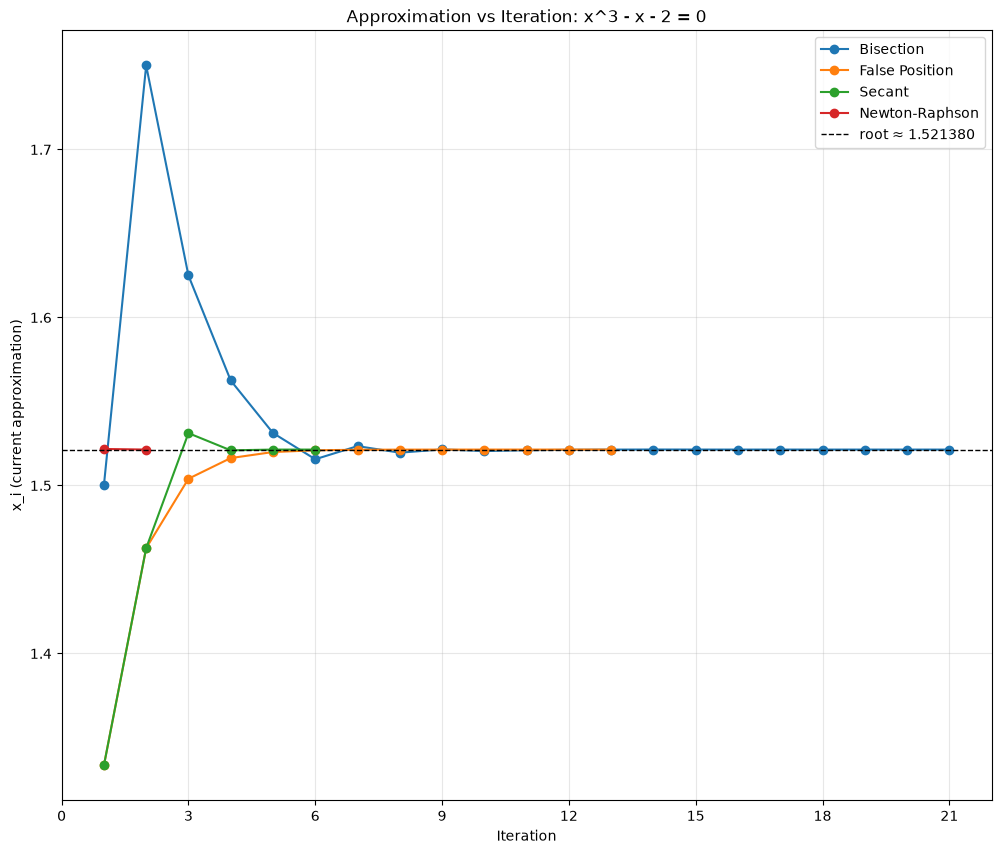

In [27]:
from matplotlib.ticker import MaxNLocator


def run_iteration_plot():
    label = COMPARISON["label"]
    func = COMPARISON["func"]
    dfunc = COMPARISON["dfunc"]
    a, b, x0, eps = COMPARISON["a"], COMPARISON["b"], COMPARISON["x0"], COMPARISON["eps"]

    results = {
        "Bisection": bisection(func, a, b, eps),
        "False Position": false_position(func, a, b, eps),
        "Secant": secant(func, a, b, eps),
        "Newton-Raphson": newton_raphson(func, dfunc, x0, eps),
    }

    # per-method: index of the current approximation x_i within its rows tuple
    x_extractors = {
        "Bisection": lambda rows: [r[3] for r in rows],
        "False Position": lambda rows: [r[3] for r in rows],
        "Secant": lambda rows: [r[3] for r in rows],
        "Newton-Raphson": lambda rows: [r[4] for r in rows],
    }

    root_ref = results["Newton-Raphson"][0]

    plt.figure()
    for name, (root, f_root, err, n_iter, rows) in results.items():
        x_vals = x_extractors[name](rows)
        plt.plot(range(1, n_iter + 1), x_vals, marker="o", label=name)

    plt.axhline(root_ref, color="black", linewidth=1, linestyle="--", label=f"root ≈ {root_ref:.6f}")
    plt.title(f"Approximation vs Iteration: {label}")
    plt.xlabel("Iteration")
    plt.ylabel("x_i (current approximation)")
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("iteration_progress.png", dpi=150, bbox_inches="tight")
    plt.show()


run_iteration_plot()
